# BBC News Classification Project
- Author: Alex Waddel
- Date: 12/6/2025
## Overview
In this Kaggle BBC News Classification project, I used a public dataset from BBC comprised of 2225 articles (text data), each labeled as either 'business', 'entertainment', 'politics', 'sport', or 'tech'. I focused on using Natural Language Processing (NLP) feature extraction techniques (specifically TF-IDF), and I then used matrix factorization techniques (specifically NMF) to cluster and then ultimately classify the articles into the 5 groups.

https://www.kaggle.com/competitions/learn-ai-bbc/overview

I show that NMF can be an effective unsupervised learning technique for breaking down large datasets into smaller meaningful clusters.

In [15]:
# Imports
import numpy as np
import pandas as pd
from pathlib import Path
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")


## Exploratory Data Analysis

In [2]:
DATA_DIR = Path.cwd() / "data"
train_df = pd.read_csv(DATA_DIR/'BBC News Train.csv')
test_df = pd.read_csv(DATA_DIR/'BBC News Test.csv')
sample_sub = pd.read_csv(DATA_DIR/'BBC News Sample Solution.csv')
train_df.head()

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


### Plot histogram of word count per article

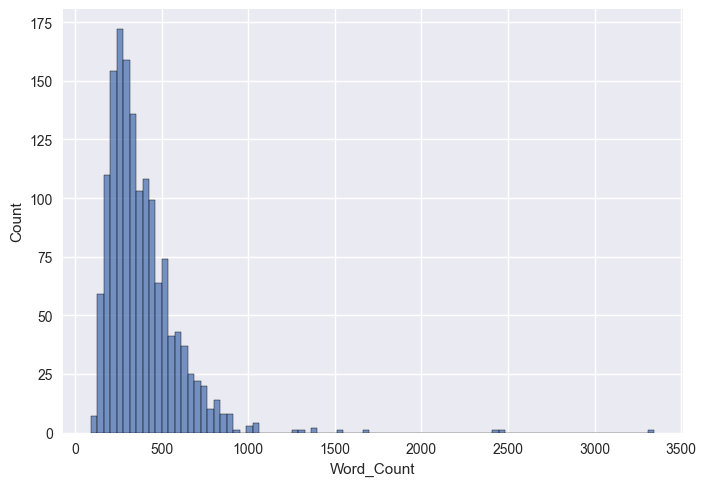

In [3]:
# Plot histogram of word count per article
train_df['Word_Count']=train_df['Text'].str.split().str.len()
sns.histplot(train_df['Word_Count']); plt.show()

The distribution of word count across the articles is roughly contained between 0-1000 words. The distribution is somewhat gaussian, but with a significant right skew.

### Plot number of articles per category in training set

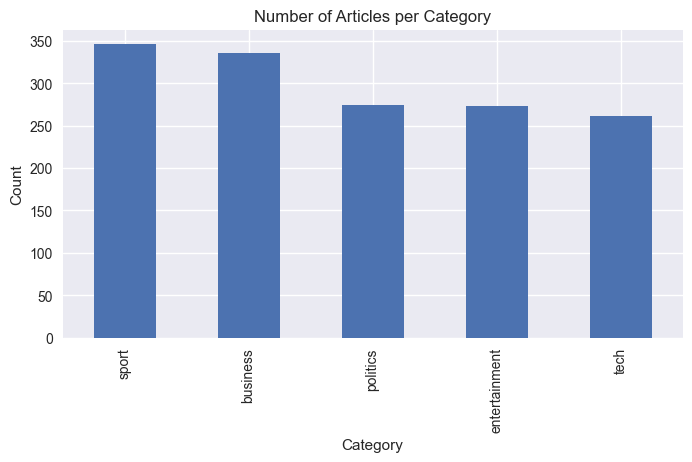

In [4]:
# Plot number of articles per category in training set
train_df['Category'].value_counts().plot(kind='bar', figsize=(8,4))
plt.title("Number of Articles per Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

This training data set is pretty well balanced between categories.

## Feature Extraction of Raw Texts

[1] In Natural Language Processing (NLP), you generally need to use some feature extraction/word embedding method in order to generate features from the raw text. For this project, I chose to use Term Frequency - Inverse Document Frequency (TF-IDF) as my feature extraction method. I chose this because:
- It generates positive value features that can be used in the matrix factorization method that I want to use (Non-negative Matrix Factorization)
- It is a relatively straightforward model to implement. There are other feature extraction methods that are much more involved, including attempting to capture context from the raw text, but TF-IDF should be sufficient for this project.

TF-IDF attempts to evaluate how important a word is to a document in relation to a larger collection of documents. This involves two components:
- Term Frequency: A measure of how often a word appears in a single document
- Inverse Document Frequecy: A measure of how common words are across multiple document. This serves to increase the weight of rare words. Note that this metric is a logarithmic function

Ultimately you multiple these two terms together to generate a TF-IDF score. These scores are always non-negative.
- TFIDF = TF * IDF

In [5]:
# Use TF-IDF to process raw texts into feature vectors
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=1000,
    norm='l2',
    max_df = 1.0,
    min_df = 1,
    )
X_train = tfidf.fit_transform(train_df['Text'])
y_train = train_df['Category']

In [6]:
feature_names = np.array(tfidf.get_feature_names_out())
sorted_idx = np.argsort(X_train.mean(axis=0).A1)[::-1]
print("Most popular 20 words across all data:")
print(feature_names[sorted_idx[:20]])

Most popular 20 words across all data:
['said' 'mr' 'year' 'new' 'people' 'film' 'world' 'time' 'uk' 'government'
 'game' 'best' 'years' '000' 'labour' 'england' 'music' 'just' 'told'
 'number']


In [7]:
def top_tfidf(category, n=10):
    idx = (train_df['Category'] == category).values
    vec = X_train[idx].mean(axis=0).A1
    top_idx = np.argsort(vec)[::-1][:n]
    return list(feature_names[top_idx])

categories = np.unique(y_train)

for c in categories:
    print(" ")
    print(f"Category '{c}' -- Top 10 TF-IDF scoring words:")
    print(top_tfidf(c))

 
Category 'business' -- Top 10 TF-IDF scoring words:
['said', 'firm', 'market', 'growth', 'company', 'mr', 'year', 'bank', 'economy', 'shares']
 
Category 'entertainment' -- Top 10 TF-IDF scoring words:
['film', 'best', 'said', 'music', 'band', 'awards', 'actor', 'star', 'award', 'album']
 
Category 'politics' -- Top 10 TF-IDF scoring words:
['mr', 'said', 'labour', 'blair', 'election', 'government', 'party', 'brown', 'minister', 'people']
 
Category 'sport' -- Top 10 TF-IDF scoring words:
['game', 'england', 'said', 'win', 'cup', 'match', 'team', 'players', 'chelsea', 'season']
 
Category 'tech' -- Top 10 TF-IDF scoring words:
['people', 'said', 'mobile', 'software', 'technology', 'users', 'microsoft', 'digital', 'net', 'computer']


## Matrix Factorization Unsupervised Classification Model

[2] Non-negative Matrix Factorization (NMF) is a linear algebra technique used to break down large datasets into smaller meaningful parts while ensuring that all values remain non-negative. This will be helpful in extracting useful features, and it will work well with my TF-IDF scheme. Note that we SHOULD NOT include texts from the dataset in the NMF model, as this is a linear algrebra method that process numerical values in matrices.

For some input matrix with dimensions (M, N) where N = number of words and M = number of articles, the NMF will output two matrices (K, N) and (M, K) that represent the matrix of words by topics and the matrix of topics by articles respectively.

We can use these outputs to check the predicted class and the true category. Since we effectively should not have labels (unsupervised), that makes this a clustering problem, not a classification problem. Thus we cluster data into groups, but we won't have class labels associated with each group. We will need to do an extra step to look into the true labels after the fact to associate each "cluster" with an article "category". Then we can compare results as if this was a classification problem. In my code below I've included code to do that extra cluster --> category functionality. I've also implemented this as a custom classifier class so that we can use it in a grid search cross validation method later on.

In [8]:
# Need to build custom NMF class so I can use sklearn gridsearch later
class CustomNMFClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_components=5):
        self.n_components = n_components

    def fit(self, X, y):
        y = np.asarray(y)
        categories = np.unique(y)

        # Fit NMF on *this* data (TF-IDF output)
        self.nmf = NMF(
            n_components=self.n_components,
            random_state=22
        )
        self.nmf.fit(X)

        # Transform training fold
        W = self.nmf.transform(X)
        y_pred = np.argmax(W, axis=1)

        # Find best permutation mapping
        best_perm = None
        best_score = -1

        for perm in itertools.permutations(range(len(categories))):
            mapped = np.array([categories[perm[i]] for i in y_pred])
            score = np.mean(mapped == y)
            if score > best_score:
                best_score = score
                best_perm = perm

        # Store mapping dictionary
        self.nmf_category_labels = {
            i: categories[best_perm[i]]
            for i in range(len(categories))
        }

        return self

    def predict(self, X):
        W = self.nmf.transform(X)
        y_pred = np.argmax(W, axis=1)
        mapped = [self.nmf_category_labels[i] for i in y_pred]
        return np.array(mapped)


Let's use this code with default hyperparameters on the training data to see how we perform:

In [9]:
# First we'll fit and assess to the training data
nmf = CustomNMFClassifier(n_components=5)
X_train = tfidf.fit_transform(train_df['Text'])
nmf.fit(X_train, y_train)
y_pred_train = nmf.predict(X_train)
acc = accuracy_score(y_train, y_pred_train)
print(f"Training Classification Accuracy: {acc}")

# Now we'll test prediction with the test data
X_test = tfidf.transform(test_df['Text'])
y_pred_test = nmf.predict(X_test)
sub_df = pd.DataFrame({
    "ArticleId": test_df["ArticleId"],
    "Category": y_pred_test,
})
sub_df.to_csv("submission_nmf_notune.csv", index=False)


Training Classification Accuracy: 0.8885906040268456


## Tune Hyperparameters of TFIDF-NMF
We performed pretty well in the initial run of our TDIDF NMF model. Let's see if we can tune the hyperparameters to optimize the performance. We will use grid search cross validation to do so.

In [10]:
# Use grid search cross validation to fine optimal hyperparameters
X_train_gridsearch = train_df['Text']
y_train = train_df['Category']

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(norm="l2")),
    ("nmf", CustomNMFClassifier(n_components=5)),
])
param_grid = {
    "tfidf__max_features": [None, 1000, 3000, 5000],
    "tfidf__max_df": [0.4, 0.6, 0.8, 1.0],
    "tfidf__min_df": [1, 2, 4],
}
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
)

grid.fit(X_train_gridsearch, y_train)

print("Best score:", grid.best_score_)
print("Best params:", grid.best_params_)

# Evaluate results for training data
y_pred = grid.best_estimator_.predict(X_train_gridsearch)
print(classification_report(y_train, y_pred))


Best score: 0.9181338028169014
Best params: {'tfidf__max_df': 0.4, 'tfidf__max_features': None, 'tfidf__min_df': 2}
               precision    recall  f1-score   support

     business       0.90      0.93      0.92       336
entertainment       0.96      0.81      0.88       273
     politics       0.93      0.88      0.91       274
        sport       0.97      0.99      0.98       346
         tech       0.82      0.95      0.88       261

     accuracy                           0.92      1490
    macro avg       0.92      0.91      0.91      1490
 weighted avg       0.92      0.92      0.92      1490



By tuning our hyperparameters, we were able to increase the accuracy of our model on the training data. The grid search cross validation yielded the hyperparameters shown above as the "best model" -- yielding an accuracy of 0.918.

In [11]:
# Evaluate test data and generate submission
X_test = test_df['Text']
y_pred_test = grid.best_estimator_.predict(X_test)
sub_df = pd.DataFrame({
    "ArticleId": test_df["ArticleId"],
    "Category": y_pred_test,
})
sub_df.to_csv("submission_nmf_tuned.csv", index=False)

## Improving Model Performance

I went back to the TFIDF-NMF model to see if I could improve the model performance.

I attempted to alter the feature extraction method in order to achieve better results. To do so, I added the TF-IDF model to the grid search CV method above. I wanted to check if altering the TF-IDF settings could improve the overall model. I was able to see slight increase in accuracy but couldn't improve the accuracy past 0.918.

## TFIDF-NMF Model Results

In [ ]:
nmf_results = {
    "Model": ["Unsupervised NMF Original", "Unsupervised NMF Tuned"],
    "Training Data Accuracy": [acc, grid.best_score_],
    "Test Data Accuracy": [0.89251, 0.93469],
}
nmf_results = pd.DataFrame(nmf_results)
nmf_results = nmf_results.style.hide(axis="index")
nmf_results


Model,Training Data Accuracy,Test Data Accuracy
Unsupervised NMF Original,0.888591,0.892510
Unsupervised NMF Tuned,0.918134,0.934690


As seen in the table, I was able to tune and improve the NMF model into some marginal gains. Interestingly, the model accuracies were similar but better against the Kaggle test dataset. This is a good sign that there is not overfitting happening within the model. Generally the tuned model performance was good, clocking in at >90% accuracy against both the training and testing data.

## Supervised Logistic Regression

In [14]:
clf_sup = LogisticRegression(max_iter=500)
clf_sup.fit(X_train, y_train)
print(f"Supervised LR Accuracy: {clf_sup.score(X_train, y_train)}")

Supervised LR Accuracy: 0.9892617449664429


## Training Data Size Effect on Performance

In [26]:
train_data_sizes = [0.1, 0.2, 0.5, 1.0]
nmf_train_acc = []
lr_train_acc = []

for ts in train_data_sizes:
    # Split training data
    if ts == 1.0:
        X_train_subset = train_df['Text']
        y_train_subset = train_df['Category']
    else:
        X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(train_df['Text'], train_df['Category'], train_size=ts)
                                                                                    
    # NMF train
    tuned_nmf = grid.best_estimator_
    tuned_nmf.fit(X_train_subset, y_train_subset)
    y_pred = tuned_nmf.predict(X_train_subset)
    nmf_train_acc.append(accuracy_score(y_train_subset, y_pred))

    # NMF test
    X_test = test_df['Text']
    y_pred_test = tuned_nmf.predict(X_test)
    sub_df = pd.DataFrame({
        "ArticleId": test_df["ArticleId"],
        "Category": y_pred_test,
    })
    sub_df.to_csv(f"submission_nmf_tuned_{ts}_trainsize.csv", index=False)

    # LR train
    X_train_lr = tfidf.fit_transform(X_train_subset)
    clf_sup.fit(X_train_lr, y_train_subset)
    lr_train_acc.append(clf_sup.score(X_train_lr, y_train_subset))

    # LR test
    X_test = test_df['Text']
    X_test_lr = tfidf.fit_transform(X_test)
    y_pred_test = clf_sup.predict(X_test_lr)
    sub_df = pd.DataFrame({
        "ArticleId": test_df["ArticleId"],
        "Category": y_pred_test,
    })
    sub_df.to_csv(f"submission_lr_{ts}_trainsize.csv", index=False)
    

In [28]:
# Generate table
nmf_test_acc = [0.83401, 0.90204, 0.94149, 0.93469]
lr_test_acc = [0.27074, 0.38231, 0.43945, 0.65306]

ts_results = {
    "Model / Eval Data": ["NMF / Training Data", "NMF / Kaggle Test Data", "LR / Training Data", "LR / Kaggle Test Data"],
    "10% Train Data": [nmf_train_acc[0], nmf_test_acc[0], lr_train_acc[0], lr_test_acc[0]],
    "20% Train Data": [nmf_train_acc[1], nmf_test_acc[1], lr_train_acc[1], lr_test_acc[1]],
    "50% Train Data": [nmf_train_acc[2], nmf_test_acc[2], lr_train_acc[2], lr_test_acc[2]],
    "100% Train Data": [nmf_train_acc[3], nmf_test_acc[3], lr_train_acc[3], lr_test_acc[3]],
}
ts_results = pd.DataFrame(ts_results)
ts_results = ts_results.style.hide(axis="index")
ts_results

Model / Eval Data,10% Train Data,20% Train Data,50% Train Data,100% Train Data
NMF / Training Data,0.791946,0.875839,0.923490,0.916107
NMF / Kaggle Test Data,0.834010,0.902040,0.941490,0.934690
LR / Training Data,1.000000,1.000000,0.991946,0.989262
LR / Kaggle Test Data,0.270740,0.382310,0.439450,0.653060


- The unsupervised NMF model performed quite well even for small training data sets, achieving ~80% accuracy using only 10% of the available training data. This model also performed qutie similarly when evaluated for the training data vs the kaggle test data. Overall this would lead me to believe that this unsupervised NMF model is quite effective for small data sets, and not prone to overfitting.

- On the other hand, the supervised Logistic Regression model always performed well when evaluated against the training data, however it always performed poorly against the kaggle test dataset. This is a clear sign that the LR model with these parameters is very prone to overfitting, and generally does not perform well with small training data sets.

## References
1. https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/
2. https://www.geeksforgeeks.org/machine-learning/non-negative-matrix-factorization/
3. https://www.kaggle.com/code/desireedisco/bbc-category-project-wk4#NMF-and-TF-IDF
4. https://www.kaggle.com/competitions/learn-ai-bbc/overview